In [37]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
# from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator, StatevectorSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes,RZGate, PauliEvolutionGate, HamiltonianGate
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.ticker as ticker
#from qiskit.circuit.library.generalized_gates import RXXGate, RYYGate, RZZGate
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import RGate, ZGate, MCXGate
from qiskit.circuit import Gate
from scipy.linalg import expm
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
from qiskit_ibm_runtime import SamplerV2 as Sampler
#from tqdm import tqdm
import time
from qiskit.quantum_info import Operator
from qiskit.providers import JobStatus
from qiskit_aer import Aer

In [38]:
from qiskit.quantum_info import Operator, Pauli
from qiskit.quantum_info.operators import SparsePauliOp
from scipy.linalg import expm
from scipy.linalg import svd
from scipy.constants import physical_constants
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector

In [39]:
# noiseless implementation
#sampler = StatevectorSampler()
simulator=AerSimulator(method="matrix_product_state")
#simulator = Aer.get_backend("qasm_simulator")

In [40]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####

def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP, cp_sign=1):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP * cp_sign)
    e_ideltap = np.exp(1j * delta_CP * cp_sign)

    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_ideltap, c12 * c23 - s12 * s23 * s13 * e_ideltap, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_ideltap, -c12 * s23 - s12 * c23 * s13 * e_ideltap, c23 * c13]
    ], dtype=complex)

    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U
    return U_4x4


theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0
N = 16

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
print(mu)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
print (omega, Omega)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

def theta_ij(i, j):
    return np.arccos(0.9) * np.abs(i-j) / (N-1)

def J_ij(i, j, E):
    return  mu/(N) * (1 - np.cos(theta_ij(i, j))) * 1
print(theta_ij(0,1))
print (J_ij(0,1,E))

0.02004
3.705e-05 0.0012525
0.030068454119750825
5.66157440399615e-07


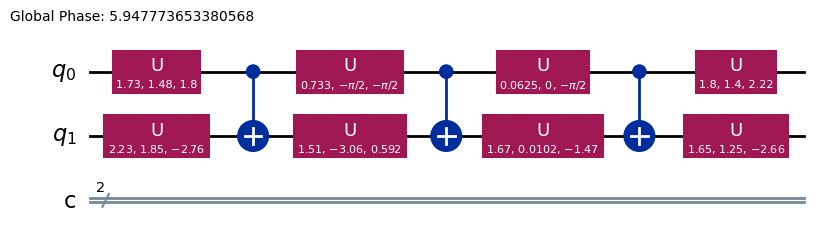

In [41]:
qc=QuantumCircuit(2,2)
Udag = Operator(U_PMNS_4x4.conj().T)
qc.unitary(Udag, [0,1], label="U†_PMNS")
qc.decompose().draw('mpl')

In [42]:
def U1_omega_Omega(t):
    A = -1 * omega * t
    B_val = -1 * Omega * t
    gate = QuantumCircuit(2)
    gate.rz(A, 0)
    gate.rz(B_val, 1)
    return gate.to_gate(label='U1_omega_Omega')


In [43]:
def nunu_interaction(qc, q, alpha):
    a, b, c, d = q
    qc.cx(a, c)
    qc.cx(b, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(c, a)
    qc.cx(d, b)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.rz(-alpha, c)
    qc.rz(-alpha, d)
    qc.cx(a, c)
    qc.cx(b, d)
    qc.cx(a, b)
    qc.rz(-2 * alpha, b)
    qc.rz(alpha, c)
    qc.rz(alpha, d)
    qc.cx(a, b)
    qc.cx(b, c)
    qc.rz(alpha, c)
    qc.cx(a, c)
    qc.rz(-alpha, c)
    qc.cx(a, d)
    qc.cx(b, c)
    qc.rz(alpha, d)
    qc.cx(b, d)
    qc.rz(-alpha, d)
    qc.cx(a, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(d, b)
    qc.cx(c, a)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.cx(b, d)
    qc.cx(a, c)

In [44]:
def apply_nunu_interaction(qc, pair_indices, alpha_list):
    for i, j, alpha_ij in alpha_list:
        q = [2*i, 2*i+1, 2*j, 2*j+1]
        nunu_interaction(qc, q, alpha_ij)


In [ ]:
# Time loop setup for N neutrinos

pair_indices = [(i, j) for i in range(N) for j in range(i+1, N)]
dt = 5 / mu
T_max = 20 / mu
steps = int(T_max / dt) + 1
times = np.linspace(0, T_max, steps)

probabilities = []
shots = 8192
for t in times:
    qc = QuantumCircuit(2 * N, 2 * N)

    # Initial state: alternate nu_e, nu_mu, nu_e, nu_tau pattern
    for i in range(N):
        if i % 4 == 1:
            qc.x(2*i + 1)  # nu_mu = |01⟩
        elif i % 4 == 3:
            qc.x(2*i)      # nu_tau = |10⟩

    # Apply U†_PMNS
    Udag = Operator(U_PMNS_4x4.conj().T)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS")

    # Trotterization
    Trotter = int(t / dt)
    for _ in range(Trotter):
        pair_alphas = [(i, j, J_ij(i, j, E) * dt) for i, j in pair_indices]
        for i in range(N):
            qc.append(U1_omega_Omega(dt), [2*i, 2*i+1])

        apply_nunu_interaction(qc, pair_indices, pair_alphas)

    # Apply U_PMNS
    U = Operator(U_PMNS_4x4)
    for i in range(N):
        qc.unitary(U, [2*i, 2*i+1], label="U_PMNS")

    # Measurement
    qc.measure(range(2 * N), reversed((range(2 * N))))
    pqc = transpile(qc, simulator)
    #print(qc.count_ops())
    #for instr, qargs, cargs in qc.data:
        #if hasattr(instr, "params") and instr.params:
           # print(f"{instr.name}: {instr.params}")

    #pqc = transpile(qc, basis_gates=["u3", "cx"])
    job = simulator.run([pqc], shots=shots)
    job_result = job.result()
    counts = job_result.get_counts()

    # Target initial state pattern: 00 01 00 10 00 01 00 10 ...
    # Target initial state pattern based on same logic as initial state
    base_pattern = []
    for i in range(N):
        if i % 4 == 1:
            base_pattern.append('01')  # nu_mu
        elif i % 4 == 3:
            base_pattern.append('10')  # nu_tau
        else:
            base_pattern.append('00')  # nu_e
    # Reverse the *pairs*, not individual bits
    target_state = ''.join((base_pattern))

    #print("Target state:", target_state)
    

    prob = counts.get(target_state, 0) / shots
    print("Measurement counts:", counts)
    probabilities.append(prob)

# Plot
plt.plot(times * mu, probabilities, marker='o')
plt.xlabel(r"Time ($\mu^{-1}$)")
plt.ylabel("P(initial → initial)")
plt.title("Survival Probability of 20-Neutrino State")
plt.grid(True)
plt.show()


Measurement counts: {'00010010000100100001001000010010': 8192}
